<a href="https://colab.research.google.com/github/elizafhilip-png/TugasDataMining/blob/main/Latihan%205/2304020183_Eliza%20Fhilip%20Sandjaya_Tugas%20Data%20Mining%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ================================
# IMPORT LIBRARY
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# untuk clustering
from sklearn.cluster import KMeans

# untuk scaling (biar hasil lebih bagus)
from sklearn.preprocessing import StandardScaler

# ================================
# UPLOAD FILE
# ================================
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


Tahap ini digunakan untuk mengimpor library yang dibutuhkan, seperti pandas dan numpy untuk pengolahan data, matplotlib dan seaborn untuk visualisasi, serta K-Means dan StandardScaler dari sklearn untuk proses clustering dan standarisasi data.

In [4]:
# ================================
# LOAD DATASET
# ================================
df = pd.read_csv('Mall_Customers.csv')

print("=== Data Awal ===")
print(df.head())

print("\n=== Info Data ===")
print(df.info())

print("\n=== Statistik Data ===")
print(df.describe())

=== Data Awal ===
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

=== Info Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

=== Statistik

Dataset dibaca menggunakan pandas dan disimpan dalam bentuk DataFrame. Kemudian ditampilkan beberapa data awal, informasi struktur data, serta statistik deskriptif untuk memahami kondisi data.

In [5]:
# ================================
# PEMILIHAN FITUR
# ================================
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


Dipilih variabel yang relevan untuk clustering, yaitu Annual Income dan Spending Score, karena keduanya mewakili karakteristik perilaku pelanggan.

In [6]:
# ================================
# SCALING DATA
# ================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


Data distandarisasi menggunakan StandardScaler agar semua variabel memiliki skala yang sama, sehingga hasil clustering menjadi lebih akurat.

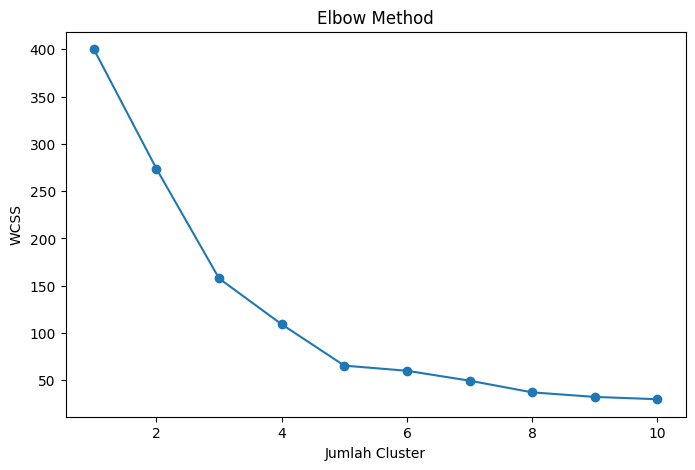

In [7]:
# ================================
# ELBOW METHOD
# ================================
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.show()

Digunakan untuk menentukan jumlah cluster terbaik dengan melihat grafik WCSS. Titik tekukan pada grafik menunjukkan jumlah cluster yang optimal.

In [8]:
# ================================
# K-MEANS CLUSTERING
# ================================
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Tambahkan ke dataset
df['Cluster'] = y_kmeans

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


Algoritma K-Means digunakan untuk mengelompokkan data ke dalam beberapa cluster. Hasilnya berupa label cluster yang ditambahkan ke dalam dataset.

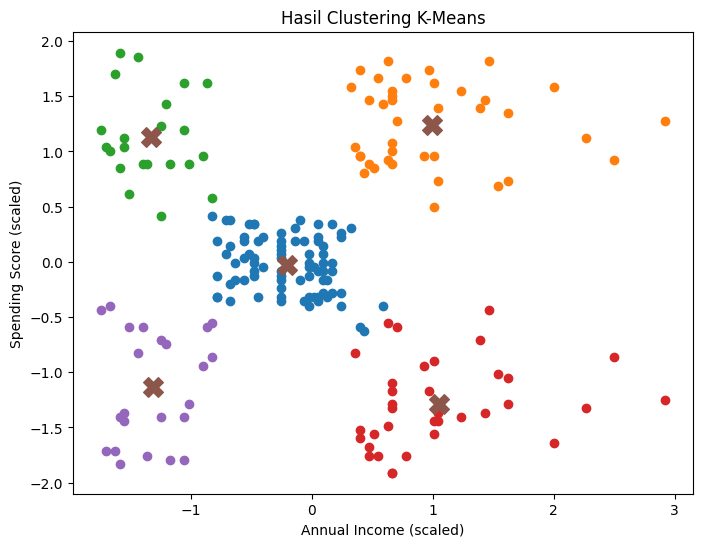

In [9]:
# ================================
# VISUALISASI CLUSTER
# ================================
plt.figure(figsize=(8,6))

plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1])
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1])
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1])
plt.scatter(X_scaled[y_kmeans == 3, 0], X_scaled[y_kmeans == 3, 1])
plt.scatter(X_scaled[y_kmeans == 4, 0], X_scaled[y_kmeans == 4, 1])

# centroid
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=200, marker='X')

plt.title('Hasil Clustering K-Means')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.show()

Hasil clustering divisualisasikan menggunakan scatter plot agar pola pengelompokan data lebih mudah dipahami.

In [11]:
# ================================
# ANALISIS CLUSTER (AMAN)
# ================================
print(df.groupby('Cluster').mean(numeric_only=True))

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043


Dilakukan perhitungan rata-rata tiap variabel pada setiap cluster untuk mengetahui karakteristik masing-masing kelompok.

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


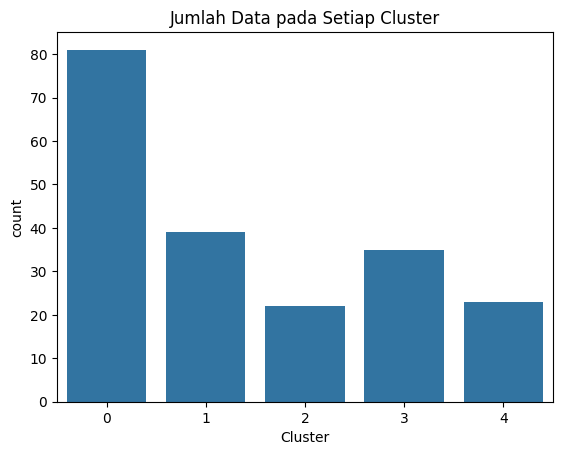

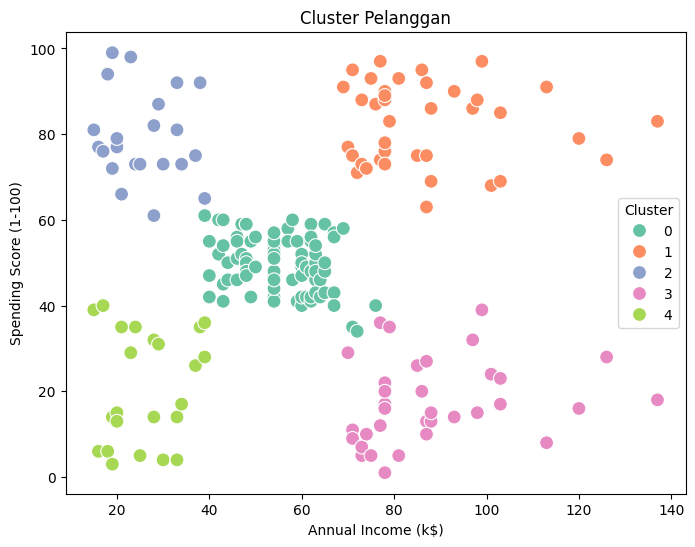

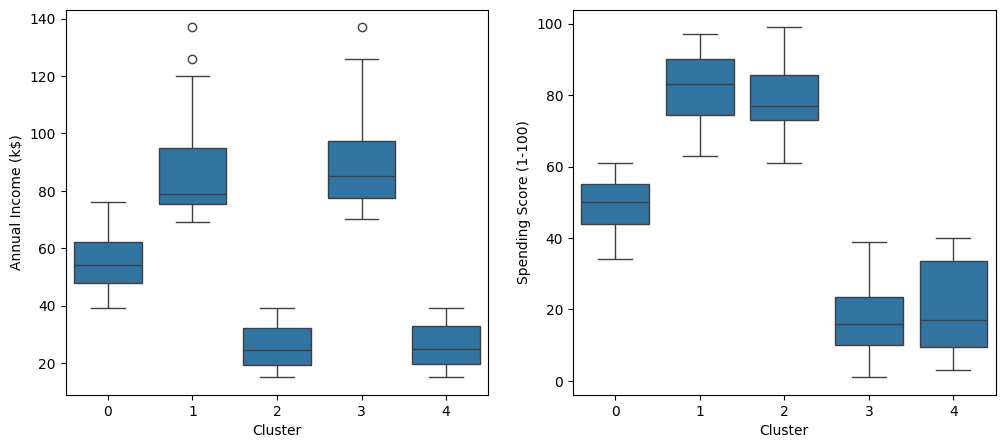

   Cluster  Kategori
0        4    Random
1        2  Menengah
2        4    Random
3        2  Menengah
4        4    Random
Silhouette Score: 0.5546571631111091


In [14]:
# ================================
# EVALUASI MODEL
# ================================

# Jumlah Data Tiap Cluster
print(df['Cluster'].value_counts())


# Rata-rata Tiap Cluster
cluster_summary = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
})

print(cluster_summary)


# Visualisasi Jumlah Cluster
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Cluster', data=df)
plt.title('Jumlah Data pada Setiap Cluster')
plt.show()


# Visualisasi Scatter
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    data=df,
    s=100
)

plt.title('Cluster Pelanggan')
plt.show()


# Boxplot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x='Cluster', y='Annual Income (k$)', data=df)

plt.subplot(1,2,2)
sns.boxplot(x='Cluster', y='Spending Score (1-100)', data=df)

plt.show()


# Label Interpretasi
def label_cluster(row):
    if row['Cluster'] == 0:
        return 'Hemat'
    elif row['Cluster'] == 1:
        return 'Boros'
    elif row['Cluster'] == 2:
        return 'Menengah'
    elif row['Cluster'] == 3:
        return 'Target Premium'
    else:
        return 'Random'

df['Kategori'] = df.apply(label_cluster, axis=1)

print(df[['Cluster', 'Kategori']].head())


# Silhouette Score (Evaluasi Cluster)
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", score)

Kualitas clustering dievaluasi menggunakan Silhouette Score. Nilai yang lebih tinggi menunjukkan hasil clustering yang lebih baik.